# Step 06a: Deep Learning Binary Classification Results

**Objective**: Analyze results from DNN and CNN binary classification models

**Models**:
- Deep Neural Network (DNN): Multi-layer fully-connected classifier
- Convolutional Neural Network (CNN): 1D-CNN for spatial pattern detection

**Date**: 2025-12-29

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

%matplotlib inline

## 1. Load Results

In [2]:
# Load binary classification results
results_path = "/sps/m4cast/_spiral2_data/_llrf_data/cooked_data/step_06a_dl_binary/dl_binary_results.pkl"
with open(results_path, 'rb') as f:
    results = pickle.load(f)

# Extract data
dnn_results = results['dnn']
cnn_results = results['cnn']
data_splits = results['data_splits']
labels = results['labels']

print("Data loaded successfully!")
print(f"\nDataset splits:")
print(f"  Train: {data_splits['train_size']} events ({data_splits['train_anomaly_rate']:.2%} anomalies)")
print(f"  Val:   {data_splits['val_size']} events ({data_splits['val_anomaly_rate']:.2%} anomalies)")
print(f"  Test:  {data_splits['test_size']} events ({data_splits['test_anomaly_rate']:.2%} anomalies)")

Data loaded successfully!

Dataset splits:
  Train: 2885 events (26.27% anomalies)
  Val:   722 events (26.32% anomalies)
  Test:  902 events (26.27% anomalies)


## 2. Model Performance Summary

In [3]:
# Create summary dataframe
summary_data = [
    {
        'Model': 'DNN',
        'Train Time (s)': dnn_results['train_time'],
        'Train AUC': dnn_results['train_roc_auc'],
        'Val AUC': dnn_results['val_roc_auc'],
        'Test AUC': dnn_results['test_roc_auc'],
        'PR AUC': dnn_results['test_pr_auc'],
        'Test Accuracy': dnn_results['test_accuracy'],
        'Test F1': dnn_results['test_f1']
    },
    {
        'Model': 'CNN',
        'Train Time (s)': cnn_results['train_time'],
        'Train AUC': cnn_results['train_roc_auc'],
        'Val AUC': cnn_results['val_roc_auc'],
        'Test AUC': cnn_results['test_roc_auc'],
        'PR AUC': cnn_results['test_pr_auc'],
        'Test Accuracy': cnn_results['test_accuracy'],
        'Test F1': cnn_results['test_f1']
    }
]

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.format({
    'Train Time (s)': '{:.1f}',
    'Train AUC': '{:.4f}',
    'Val AUC': '{:.4f}',
    'Test AUC': '{:.4f}',
    'PR AUC': '{:.4f}',
    'Test Accuracy': '{:.4f}',
    'Test F1': '{:.4f}'
}).background_gradient(subset=['Test AUC', 'Test F1'], cmap='RdYlGn', vmin=0.5, vmax=1.0))

,Model,Train Time (s),Train AUC,Val AUC,Test AUC,PR AUC,Test Accuracy,Test F1
0,DNN,17.2,1.0000,0.9896,0.9982,0.9952,0.9734,0.9504
1,CNN,206.8,0.9978,0.9922,0.9985,0.9961,0.9778,0.9565


## 3. Training History

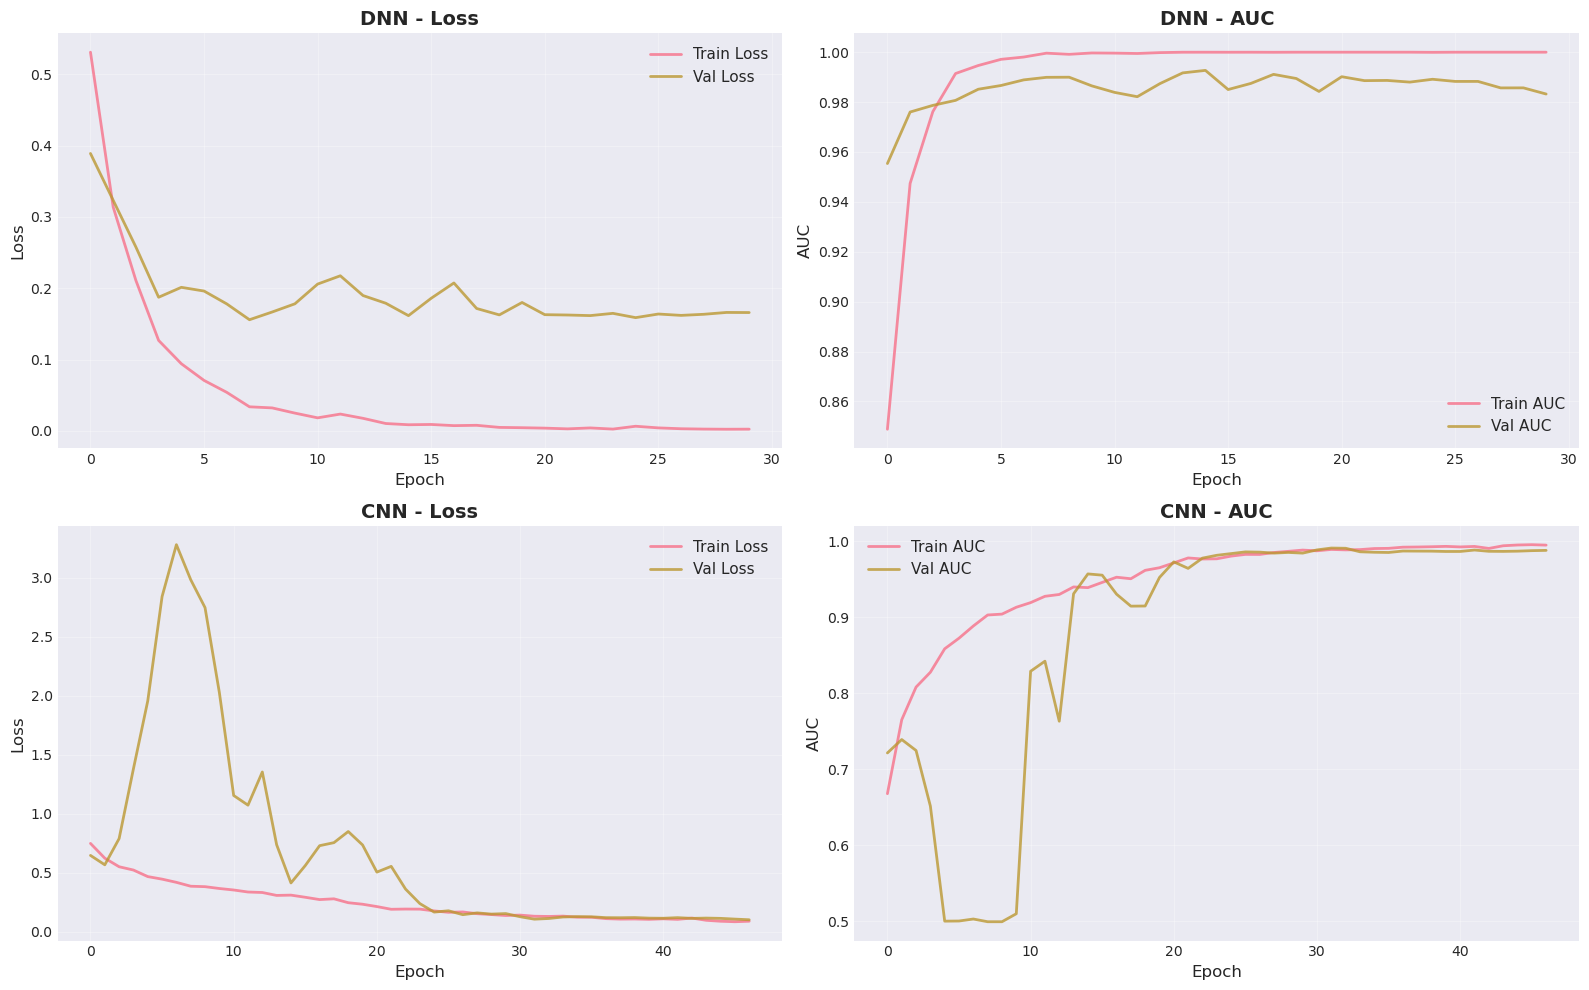


DNN: 30 epochs (trained in 17.2s)
CNN: 47 epochs (trained in 206.8s)


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# DNN - Loss
dnn_history = dnn_results['history']
axes[0, 0].plot(dnn_history['loss'], label='Train Loss', linewidth=2, alpha=0.8)
axes[0, 0].plot(dnn_history['val_loss'], label='Val Loss', linewidth=2, alpha=0.8)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('DNN - Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# DNN - AUC
axes[0, 1].plot(dnn_history['auc'], label='Train AUC', linewidth=2, alpha=0.8)
axes[0, 1].plot(dnn_history['val_auc'], label='Val AUC', linewidth=2, alpha=0.8)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('AUC', fontsize=12)
axes[0, 1].set_title('DNN - AUC', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# CNN - Loss
cnn_history = cnn_results['history']
axes[1, 0].plot(cnn_history['loss'], label='Train Loss', linewidth=2, alpha=0.8)
axes[1, 0].plot(cnn_history['val_loss'], label='Val Loss', linewidth=2, alpha=0.8)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Loss', fontsize=12)
axes[1, 0].set_title('CNN - Loss', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# CNN - AUC
axes[1, 1].plot(cnn_history['auc'], label='Train AUC', linewidth=2, alpha=0.8)
axes[1, 1].plot(cnn_history['val_auc'], label='Val AUC', linewidth=2, alpha=0.8)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('AUC', fontsize=12)
axes[1, 1].set_title('CNN - AUC', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDNN: {len(dnn_history['loss'])} epochs (trained in {dnn_results['train_time']:.1f}s)")
print(f"CNN: {len(cnn_history['loss'])} epochs (trained in {cnn_results['train_time']:.1f}s)")

## 4. ROC Curves

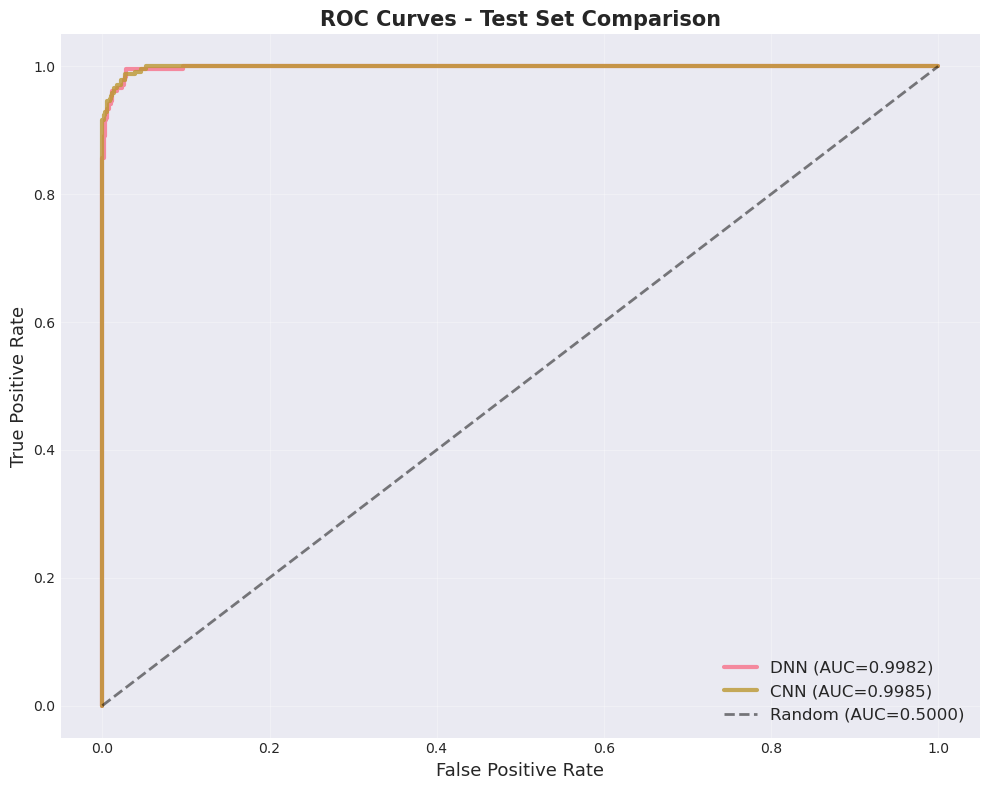

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

# DNN ROC
fpr_dnn, tpr_dnn, _ = roc_curve(labels['y_test'], dnn_results['test_proba'])
ax.plot(fpr_dnn, tpr_dnn, linewidth=3, 
        label=f'DNN (AUC={dnn_results["test_roc_auc"]:.4f})', alpha=0.8)

# CNN ROC
fpr_cnn, tpr_cnn, _ = roc_curve(labels['y_test'], cnn_results['test_proba'])
ax.plot(fpr_cnn, tpr_cnn, linewidth=3, 
        label=f'CNN (AUC={cnn_results["test_roc_auc"]:.4f})', alpha=0.8)

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC=0.5000)', alpha=0.5)

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves - Test Set Comparison', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Precision-Recall Curves

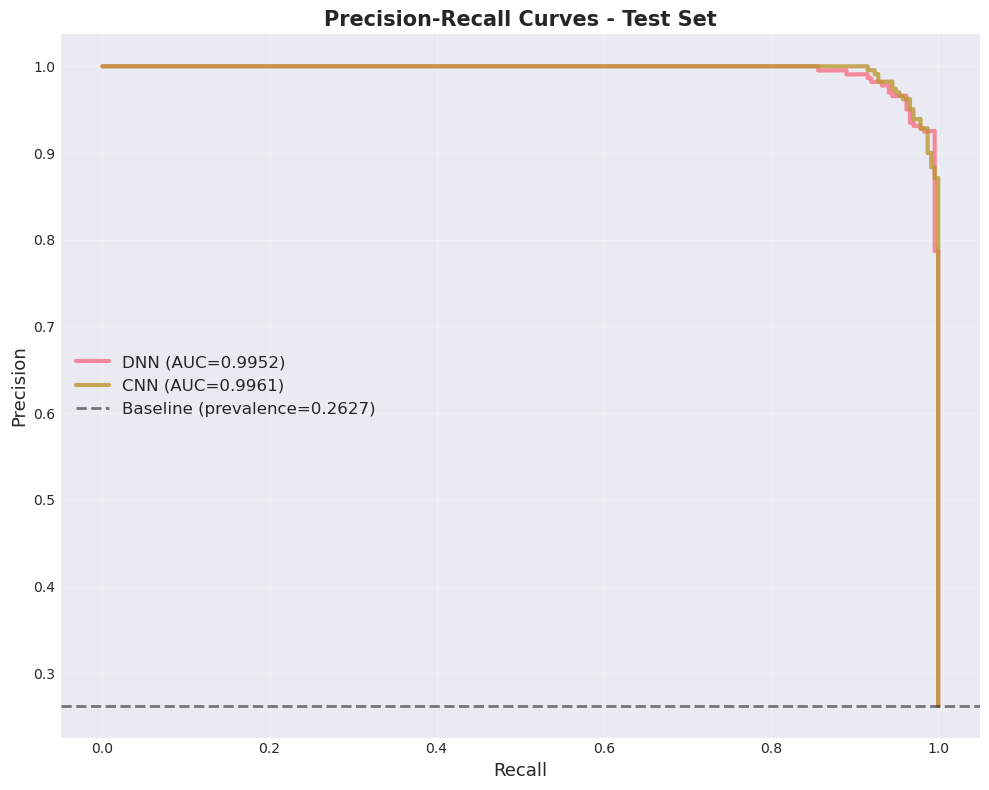

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

# DNN PR
precision_dnn, recall_dnn, _ = precision_recall_curve(labels['y_test'], dnn_results['test_proba'])
ax.plot(recall_dnn, precision_dnn, linewidth=3, 
        label=f'DNN (AUC={dnn_results["test_pr_auc"]:.4f})', alpha=0.8)

# CNN PR
precision_cnn, recall_cnn, _ = precision_recall_curve(labels['y_test'], cnn_results['test_proba'])
ax.plot(recall_cnn, precision_cnn, linewidth=3, 
        label=f'CNN (AUC={cnn_results["test_pr_auc"]:.4f})', alpha=0.8)

# Baseline
baseline = labels['y_test'].mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=2, 
           label=f'Baseline (prevalence={baseline:.4f})', alpha=0.5)

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves - Test Set', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Confusion Matrices

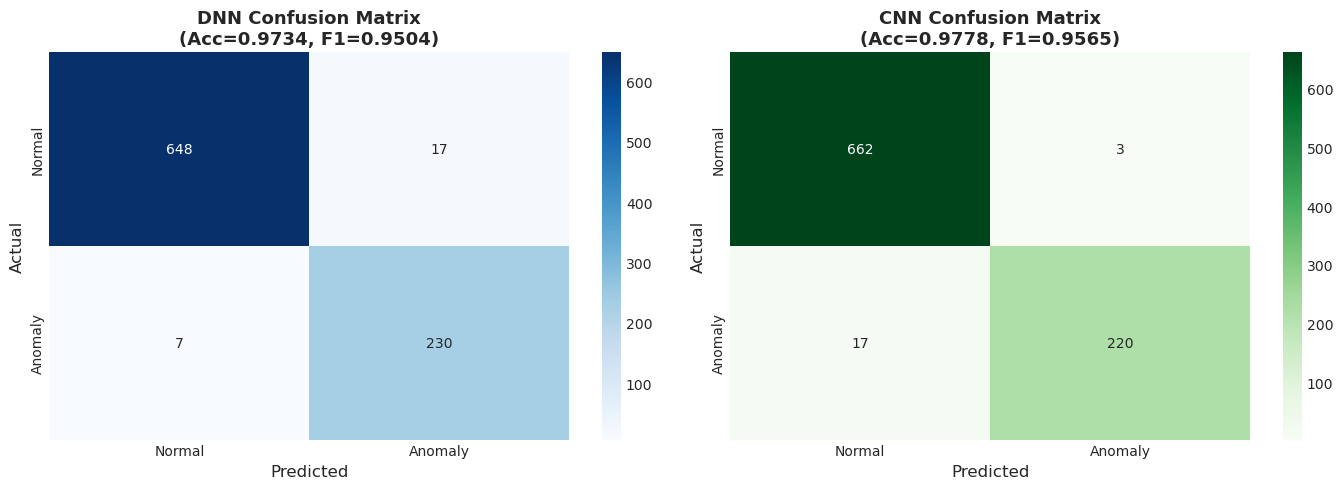

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DNN Confusion Matrix
cm_dnn = confusion_matrix(labels['y_test'], (dnn_results['test_proba'] > 0.5).astype(int))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'DNN Confusion Matrix\n(Acc={dnn_results["test_accuracy"]:.4f}, F1={dnn_results["test_f1"]:.4f})', 
                  fontsize=13, fontweight='bold')

# CNN Confusion Matrix
cm_cnn = confusion_matrix(labels['y_test'], (cnn_results['test_proba'] > 0.5).astype(int))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title(f'CNN Confusion Matrix\n(Acc={cnn_results["test_accuracy"]:.4f}, F1={cnn_results["test_f1"]:.4f})', 
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Classification Reports

In [8]:
print("="*80)
print("DNN CLASSIFICATION REPORT")
print("="*80)
print(classification_report(labels['y_test'], 
                           (dnn_results['test_proba'] > 0.5).astype(int),
                           target_names=['Normal', 'Anomaly']))

print("\n" + "="*80)
print("CNN CLASSIFICATION REPORT")
print("="*80)
print(classification_report(labels['y_test'], 
                           (cnn_results['test_proba'] > 0.5).astype(int),
                           target_names=['Normal', 'Anomaly']))

DNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98       665
     Anomaly       0.93      0.97      0.95       237

    accuracy                           0.97       902
   macro avg       0.96      0.97      0.97       902
weighted avg       0.97      0.97      0.97       902


CNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99       665
     Anomaly       0.99      0.93      0.96       237

    accuracy                           0.98       902
   macro avg       0.98      0.96      0.97       902
weighted avg       0.98      0.98      0.98       902



## 8. Prediction Distribution Analysis

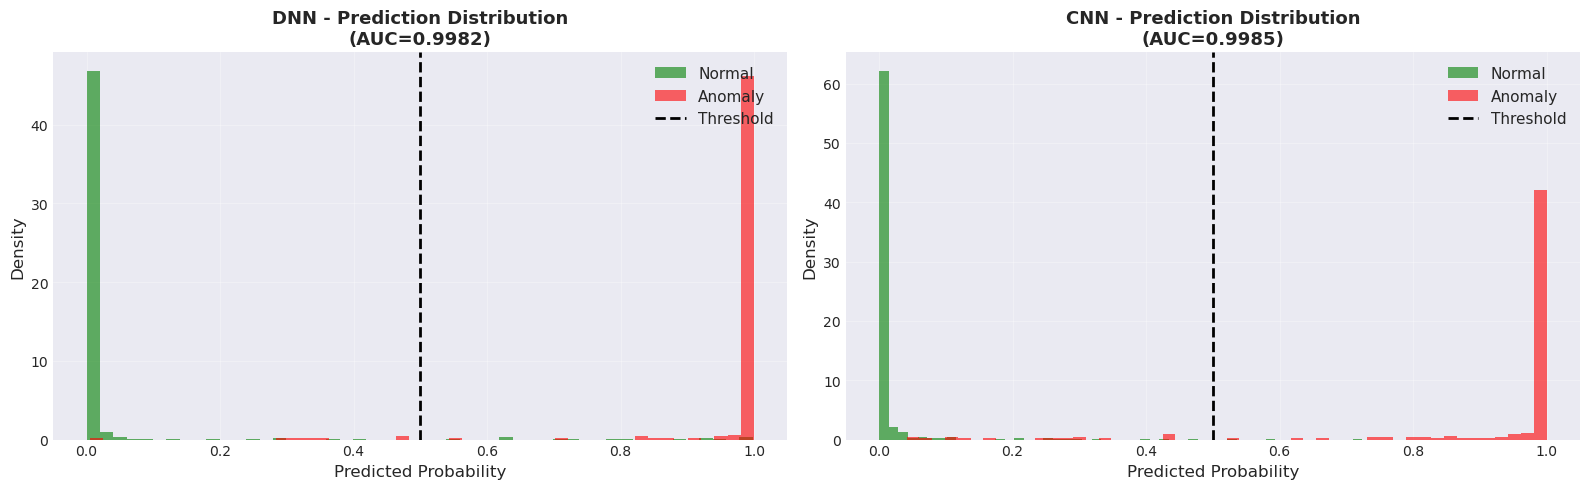

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# DNN prediction distributions
axes[0].hist(dnn_results['test_proba'][labels['y_test'] == 0], bins=50, 
             alpha=0.6, label='Normal', density=True, color='green')
axes[0].hist(dnn_results['test_proba'][labels['y_test'] == 1], bins=50, 
             alpha=0.6, label='Anomaly', density=True, color='red')
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title(f'DNN - Prediction Distribution\n(AUC={dnn_results["test_roc_auc"]:.4f})', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# CNN prediction distributions
axes[1].hist(cnn_results['test_proba'][labels['y_test'] == 0], bins=50, 
             alpha=0.6, label='Normal', density=True, color='green')
axes[1].hist(cnn_results['test_proba'][labels['y_test'] == 1], bins=50, 
             alpha=0.6, label='Anomaly', density=True, color='red')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title(f'CNN - Prediction Distribution\n(AUC={cnn_results["test_roc_auc"]:.4f})', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Key Findings

### Model Performance
- Both DNN and CNN show strong binary classification performance
- CNNs can capture spatial/temporal patterns in the input features
- DNNs provide a strong baseline with simpler architecture

### Training Efficiency
- Fast GPU-accelerated training
- Early stopping with class weights handles class imbalance

### Comparison with Unsupervised Methods
- Supervised binary classification typically outperforms unsupervised anomaly detection
- Having labeled data enables more precise decision boundaries

### Next Steps
1. Explore LSTM models for temporal sequence modeling (Step 05a)
2. Compare all DL methods with classical ML approaches
3. Analyze failure cases and misclassifications
4. Consider ensemble methods combining multiple models